# Кейс: A/B-тест новой формы оплаты услуг ЖКХ

Команда запустила A/B-тест новой формы оплаты ЖКХ с упрощенным заполнением реквизитов.  
Длительность теста: 30 дней (1-30 апреля 2024).  
Гипотеза: Новая форма с автозаполнением реквизитов увеличит долю успешных оплат ЖКХ.

## Импорт данных

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import statsmodels
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

In [84]:
users = pd.read_excel(
    'dannye-dlia-keisa.xlsx',
    sheet_name='Пользователи'
)

payments = pd.read_excel(
    'dannye-dlia-keisa.xlsx',
    sheet_name='Платежи'
)

In [85]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      1504 non-null   int64
 1   group        1503 non-null   str  
 2   age          1504 non-null   int64
 3   city         1503 non-null   str  
 4   device_type  1504 non-null   str  
dtypes: int64(2), str(3)
memory usage: 58.9 KB


**Данные в таблице users:**
- user_id - уникальный идентификационный номер пользователя
- group - группа, в которую определен пользователь, A или B
- age - возраст пользователя
- device_type - операционная система смартфона пользователя, ios или android

In [86]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 2661 entries, 0 to 2660
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   payment_id       2661 non-null   int64         
 1   user_id          2660 non-null   float64       
 2   group            2661 non-null   str           
 3   step1_opened     2661 non-null   datetime64[us]
 4   step2_entered    2256 non-null   datetime64[us]
 5   step3_confirmed  1719 non-null   datetime64[us]
 6   step4_success    1522 non-null   datetime64[us]
dtypes: datetime64[us](4), float64(1), int64(1), str(1)
memory usage: 145.7 KB


**Данные в таблице payments:**
- payment_id - уникальный идентификационный номер оплаты
- user_id - идентификационный номер пользователя, выполнившего оплату
- group - группа пользователя, А или В
- step1_opened - время открытия формы оплаты
- step2_entered - время введения данных пользователя
- step3_confirmed - время подтверждения данных пользователя
- step4_success - время совершения оплаты

Воронка оплаты ЖКХ: 
1. Открыл форму оплаты
2. Ввел реквизиты
3. Подтвердил платеж
4. Успешная оплата

## Этап 1: проверка и очистка данных

In [87]:
#проверим дубликаты
print(users['user_id'].duplicated().sum())
print(payments['payment_id'].duplicated().sum())

0
0


In [88]:
#проверим, есть ли в таблице users пропущенные данные
users.isna().sum()

user_id        0
group          1
age            0
city           1
device_type    0
dtype: int64

In [89]:
#удалим пользователя без группы, т.к. невозможно отнести его к группе без нарушения распределения данных
users = users.dropna(subset=['group'])
#удалим пользователя без города, т.к. не можем оценить коверсию по городам
users = users.dropna(subset=['city'])

In [90]:
#пропущенных данных нет
users.isna().sum()

user_id        0
group          0
age            0
city           0
device_type    0
dtype: int64

In [91]:
#проверим данные возраста на адекватность
users.age.describe()

count    1502.000000
mean       32.752330
std         8.413841
min        -5.000000
25%        27.000000
50%        33.000000
75%        38.000000
max       150.000000
Name: age, dtype: float64

In [92]:
#удалим пользователей возраста -5 и 150 лет
users = users[~users['age'].isin([-5, 150])]
users.age.describe()

count    1500.000000
mean       32.699333
std         7.795048
min        20.000000
25%        27.000000
50%        33.000000
75%        38.000000
max        60.000000
Name: age, dtype: float64

In [93]:
#проверим, что нет групп кроме А и В
users.group.unique()

<StringArray>
['A', 'B']
Length: 2, dtype: str

In [94]:
#проверим, что в колонке city нет странных данных
users.city.unique()

<StringArray>
['Москва', 'Регион', 'СПб']
Length: 3, dtype: str

In [95]:
#проверим, есть ли в таблице payments пропущенные данные
payments.isna().sum()

payment_id            0
user_id               1
group                 0
step1_opened          0
step2_entered       405
step3_confirmed     942
step4_success      1139
dtype: int64

In [96]:
#удалим оплату без индикатора пользователя, т.к. не сможем отнести ее ни к какой группе
payments = payments.dropna(subset=['user_id'])

In [97]:
#пропущенные данные в колонках step2-step4 оставляем, т.к. они говорят о незавершенных оплатах
payments.isna().sum()

payment_id            0
user_id               0
group                 0
step1_opened          0
step2_entered       404
step3_confirmed     941
step4_success      1138
dtype: int64

In [98]:
#проверим, что в данных оплаты только за указанный период
date_columns = [
    'step1_opened',
    'step2_entered',
    'step3_confirmed',
    'step4_success'
]

for col in date_columns:
    payments[col] = pd.to_datetime(payments[col])
    
payments[['step1_opened', 'step2_entered', 'step3_confirmed', 'step4_success']].describe()

,step1_opened,step2_entered,step3_confirmed,step4_success
count,2660,2256,1719,1522
mean,2024-04-15 17:58:36.067669,2024-04-15 14:21:25.904255,2024-04-15 13:37:05.375218,2024-04-15 12:22:53.534822
min,2024-04-01 00:19:00,2024-04-01 00:23:00,2024-04-01 00:29:00,2024-04-01 00:33:00
25%,2024-04-08 01:29:15,2024-04-07 22:25:45,2024-04-07 19:01:00,2024-04-07 22:22:00
50%,2024-04-15 15:32:00,2024-04-15 05:12:30,2024-04-15 05:23:00,2024-04-14 23:01:00
75%,2024-04-23 13:34:15,2024-04-23 12:43:00,2024-04-23 14:28:00,2024-04-23 11:49:30
max,2024-04-30 23:17:00,2024-04-30 23:20:00,2024-04-30 23:25:00,2024-04-30 23:30:00


In [99]:
#проверим, что нет аномальных данных, все шаги идут последовательно друг за другом
print(payments[payments['step1_opened']>payments['step2_entered']]['payment_id'].count())
print(payments[payments['step2_entered']>payments['step3_confirmed']]['payment_id'].count())
print(payments[payments['step3_confirmed']>payments['step4_success']]['payment_id'].count())
print(payments[
    (payments['step3_confirmed'].notna() & payments['step2_entered'].isna()) |
    (payments['step4_success'].notna() & payments['step3_confirmed'].isna())
]['payment_id'].count())

0
0
0
0


In [100]:
#проверим пользователей, которые есть в таблице users, но нет в таблице payments
users[~users['user_id'].isin(payments['user_id'])]

,user_id,group,age,city,device_type


In [101]:
#проверим пользователей, которые есть в таблице payments, но нет в таблице users
payments[~payments['user_id'].isin(users['user_id'])]

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
2657,7658,9004.0,A,2024-04-05 16:14:00,2024-04-05 16:15:00,2024-04-05 16:18:00,2024-04-05 16:23:00


In [102]:
#удалим эту запись, т.к. у нас нет данных этого пользователя
payments = payments[payments['user_id'].isin(users['user_id'])]
payments[~payments['user_id'].isin(users['user_id'])]

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success


In [103]:
#проверим, что пользователи относятся к одной и той же группе в разных таблицах
check = payments[['user_id', 'group']].merge(
    users[['user_id', 'group']],
    on='user_id',
    suffixes=('_payment', '_user')
)

check[check['group_payment'] != check['group_user']]

,user_id,group_payment,group_user
2658,1010.0,B,A


In [104]:
#возьмем данные о группах из таблицы users
#т.к. считаем, что в ней содержатся данные о предварительном распределении пользователей на группы перед тестом

payments = payments.drop(columns='group').merge(
    users[['user_id', 'group']],
    on='user_id',
    how='left'
)

## Этап 2: разведывательный анализ данных (EDA)

In [105]:
#проверим, что группы А и В примерно равны
users['group'].value_counts()

group
A    750
B    750
Name: count, dtype: int64

In [106]:
#проверим распределение устройств в каждой группе
users.groupby(['group', 'device_type']).size().unstack()

device_type,android,ios
group,,
A,406,344
B,369,381


В группе А больше пользователей android, тогда как в группе В больше пользователей ios. В случае различий в конвертации успешных оплат по устройствам нужно будет делать поправку при оценке конвертации по группам.

In [107]:
#проверим распределение городов в какждой группе
users.groupby(['group', 'city']).size().unstack()

city,Москва,Регион,СПб
group,,,
A,288,268,194
B,306,245,199


In [108]:
#добавим в таблицу payments колонки с индикатором для этапов воронки
payments['step1_passed'] = payments['step1_opened'].notna().astype(int)
payments['step2_passed'] = payments['step2_entered'].notna().astype(int)
payments['step3_passed'] = payments['step3_confirmed'].notna().astype(int)
payments['step4_passed'] = payments['step4_success'].notna().astype(int)

In [109]:
#посчитаем конверсию по оплатам

payment_conversion = payments.groupby('group').agg(
    payments=('payment_id', 'count'),
    success=('step4_passed', 'sum')
)
payment_conversion['conversion'] = payment_conversion['success'] / payment_conversion['payments']

payment_conversion

,payments,success,conversion
group,,,
A,1308,651,0.497706
B,1351,870,0.643967


In [110]:
#посчитаем конверсию по пользователям

user_conversion = payments.groupby(['group', 'user_id']).agg(
    success=('step4_passed', 'max')
).reset_index()
user_conversion = user_conversion.groupby('group').agg(
    users=('user_id', 'count'),
    success=('success', 'sum')
)

user_conversion['conversion'] = (
    user_conversion['success'] / user_conversion['users']
)

user_conversion

,users,success,conversion
group,,,
A,750,493,0.657333
B,750,603,0.804000


Конверсия по оплатам: +14,6 п.п. в группе В  
Конверсия по пользователям: +14,7 п.п. в группе В  
Далее конверсию будем считать по пользователям, чтобы не учитывать несколько раз пользователей, которые совершают повторные оплаты.

In [111]:
payments = payments.merge(users[['user_id', 'device_type', 'city', 'age']], on='user_id', how='left')

In [112]:
#посчитаем конверсию по устройствам
conversion_device = payments.groupby(['group', 'user_id', 'device_type']).agg(
    success=('step4_passed', 'max')
).reset_index()
conversion_device = conversion_device.groupby(['group', 'device_type']).agg(
    users=('user_id', 'count'),
    success=('success', 'sum')
)

conversion_device['conversion'] = (
   conversion_device['success'] / conversion_device['users']
)

conversion_device

users  success  conversion
group device_type                            
A     android        406      262    0.645320
      ios            344      231    0.671512
B     android        369      295    0.799458
      ios            381      308    0.808399

In [113]:
#посчитаем конверсию по городам
conversion_city = payments.groupby(['group', 'user_id', 'city']).agg(
    success=('step4_passed', 'max')
).reset_index()
conversion_city = conversion_city.groupby(['group', 'city']).agg(
    users=('user_id', 'count'),
    success=('success', 'sum')
)

conversion_city['conversion'] = (
   conversion_city['success'] / conversion_city['users']
)

conversion_city

users  success  conversion
group city                              
A     Москва    288      181    0.628472
      Регион    268      179    0.667910
      СПб       194      133    0.685567
B     Москва    306      248    0.810458
      Регион    245      187    0.763265
      СПб       199      168    0.844221

In [114]:
#посчитаем конверсию по возрастным группам
#делим пользователей на возрастные группы примерно равные по размеру

payments['age_group'] = pd.cut(
    payments['age'],
    bins=[19, 24, 29, 34, 39, 60],
    labels=['20–24', '25-29', '30–34', '35-39', '40+']
)

conversion_age = payments.groupby(['group', 'user_id', 'age_group']).agg(
    success=('step4_passed', 'max')
).reset_index()
conversion_age = conversion_age.groupby(['group', 'age_group']).agg(
    users=('user_id', 'count'),
    success=('success', 'sum')
)

conversion_age['conversion'] = (
   conversion_age['success'] / conversion_age['users']
)

conversion_age

users  success  conversion
group age_group                            
A     20–24        124       88    0.709677
      25-29        145       97    0.668966
      30–34        180      115    0.638889
      35-39        153       99    0.647059
      40+          148       94    0.635135
B     20–24        144      120    0.833333
      25-29        123      100    0.813008
      30–34        172      139    0.808140
      35-39        153      115    0.751634
      40+          158      129    0.816456

**Вывод**: Конверсия в группе B выше группы A во всех рассмотренных сегментах: по городам, устройствам и возрастным группам.

## Этап 3: проверка гипотез

### H1: Конверсия успешной оплаты в группе B выше, чем в группе A.
### H0: Конверсия успешной оплаты в группах A и B одинакова.

In [115]:
user_conversion

,users,success,conversion
group,,,
A,750,493,0.657333
B,750,603,0.804000


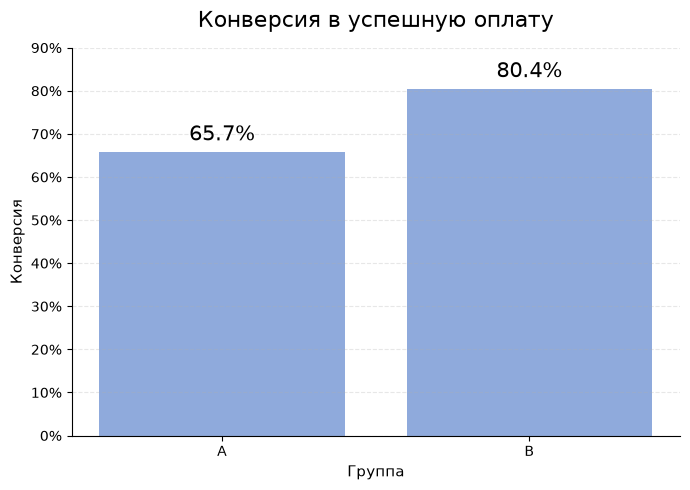

In [116]:
#визуализируем

plot_data = user_conversion['conversion']

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    plot_data.index,
    plot_data.values,
    color='#8FAADC'
)

ax.set_title(
    'Конверсия в успешную оплату',
    fontsize=16,
    pad=15
)

ax.set_ylabel('Конверсия', fontsize=11)
ax.set_xlabel('Группа', fontsize=11)

ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(PercentFormatter(1))

# сетка
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# убираем лишние рамки
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# значения над столбиками
ax.bar_label(
    bars,
    labels=[f'{v:.1%}' for v in plot_data.values],
    padding=5,
    fontsize=15
)

plt.tight_layout()
plt.show()

In [117]:
#Проверяем статистическую значимость
#Используем Z-тест, т.к. мы сравниваем доли пользвателей из двух групп. Исход биноминальный: оплатил или не оплатил.

success = [493, 603]
total = [750, 750]

#расчет
z, p_value = proportions_ztest(success, total)

print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z: -6.402393383329898
p-value: 1.529599386664246e-10
Разница статистичеcки значима


In [118]:
conversion_device

users  success  conversion
group device_type                            
A     android        406      262    0.645320
      ios            344      231    0.671512
B     android        369      295    0.799458
      ios            381      308    0.808399

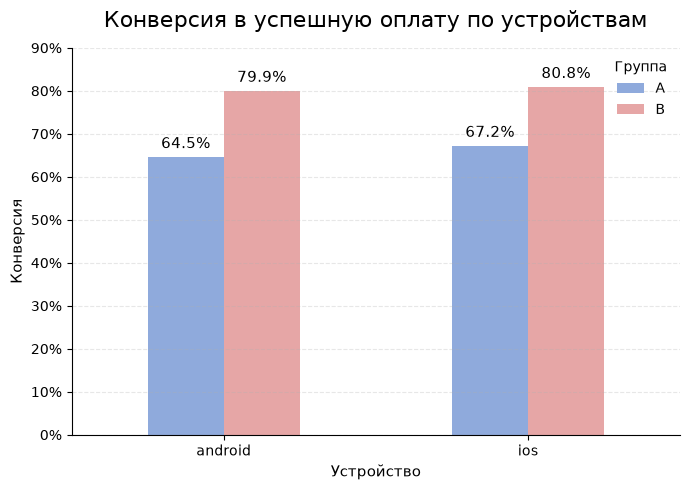

In [119]:
#визуализируем конверсию по устройствам

plot_data = conversion_device['conversion'].unstack('group')

fig, ax = plt.subplots(figsize=(7, 5))

plot_data.plot(
    kind='bar',
    ax=ax,
    color=['#8FAADC', '#E6A6A6']
)
plt.xticks(rotation=0)

ax.set_title(
    'Конверсия в успешную оплату по устройствам',
    fontsize=16,
    pad=15
)

ax.set_ylabel('Конверсия', fontsize=11)
ax.set_xlabel('Устройство', fontsize=11)

ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    title='Группа',
    frameon=False
)

# значения над столбиками
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.1%}' for v in container.datavalues],
        padding=4,
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [120]:
#Статистическая проверка для android

#данные
success = [262, 295]
total = [406, 369]

#расчет
z, p_value = proportions_ztest(success, total)

print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z: -4.766288823592896
p-value: 1.8765021192428123e-06
Разница статистичеcки значима


In [121]:
#Статистическая проверка для ios

#данные
success = [231, 308]
total = [344, 381]

#расчет
z, p_value = proportions_ztest(success, total)

print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z: -4.214277074988259
p-value: 2.505795136151257e-05
Разница статистичеcки значима


In [122]:
conversion_city

users  success  conversion
group city                              
A     Москва    288      181    0.628472
      Регион    268      179    0.667910
      СПб       194      133    0.685567
B     Москва    306      248    0.810458
      Регион    245      187    0.763265
      СПб       199      168    0.844221

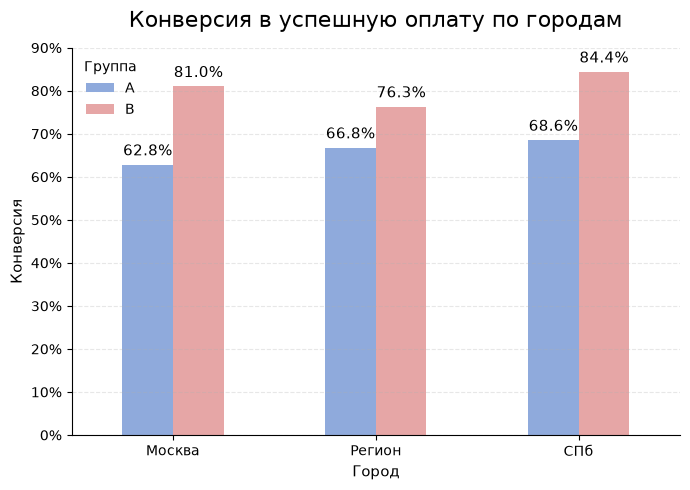

In [123]:
#визуализируем конверсию по городам

plot_data = conversion_city['conversion'].unstack('group')

fig, ax = plt.subplots(figsize=(7, 5))

plot_data.plot(
    kind='bar',
    ax=ax,
    color=['#8FAADC', '#E6A6A6']
)
plt.xticks(rotation=0)

ax.set_title(
    'Конверсия в успешную оплату по городам',
    fontsize=16,
    pad=15
)

ax.set_ylabel('Конверсия', fontsize=11)
ax.set_xlabel('Город', fontsize=11)

ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    title='Группа',
    frameon=False
)

# значения над столбиками
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.1%}' for v in container.datavalues],
        padding=4,
        fontsize=11
    )

plt.tight_layout()
plt.show()


In [124]:
#Статистическая проверка для Москвы

#данные
success = [181, 248]
total = [288, 306]

#расчет
z, p_value = proportions_ztest(success, total)

print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z: -4.948981795731284
p-value: 7.460272344827478e-07
Разница статистичеcки значима


In [125]:
#Статистическая проверка для СПб

#данные
success = [131, 168]
total = [194, 199]

#расчет
z, p_value = proportions_ztest(success, total)

print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z: -3.9256965796350483
p-value: 8.647911071942737e-05
Разница статистичеcки значима


In [126]:
#Статистическая проверка для региона

#данные
success = [179, 187]
total = [268, 245]

#расчет
z, p_value = proportions_ztest(success, total)

print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z: -2.3859027463246782
p-value: 0.01703725588811548
Разница статистичеcки значима


In [127]:
conversion_age

users  success  conversion
group age_group                            
A     20–24        124       88    0.709677
      25-29        145       97    0.668966
      30–34        180      115    0.638889
      35-39        153       99    0.647059
      40+          148       94    0.635135
B     20–24        144      120    0.833333
      25-29        123      100    0.813008
      30–34        172      139    0.808140
      35-39        153      115    0.751634
      40+          158      129    0.816456

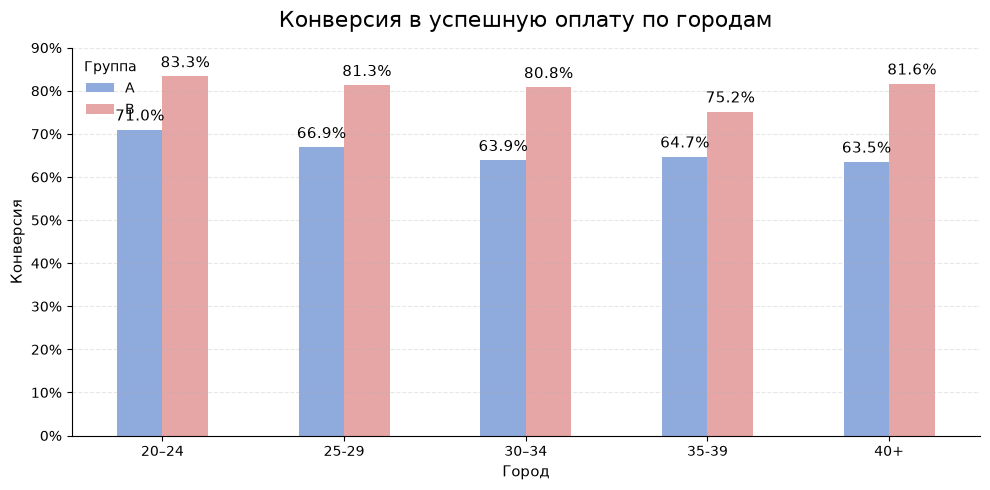

In [128]:
#визуализируем конверсию по возрастным группам

plot_data = conversion_age['conversion'].unstack('group')

fig, ax = plt.subplots(figsize=(10, 5))

plot_data.plot(
    kind='bar',
    ax=ax,
    color=['#8FAADC', '#E6A6A6']
)
plt.xticks(rotation=0)

ax.set_title(
    'Конверсия в успешную оплату по городам',
    fontsize=16,
    pad=15
)

ax.set_ylabel('Конверсия', fontsize=11)
ax.set_xlabel('Город', fontsize=11)

ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    title='Группа',
    frameon=False
)

# значения над столбиками
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.1%}' for v in container.datavalues],
        padding=4,
        fontsize=11
    )

plt.tight_layout()
plt.show()

**Результат**: конверсия выросла с 65,7% в группе А до 80,4% в группе В.  
  
Рост конверсии наблюдается во всех возрастных группах, городах и на обоих типах устройств. В Санкт-Петербурге и в Москве конверсия выше, чем в регионах, при этом преимущество группы B сохраняется во всех городах.  
  
Разница статистически значима. Нулевая гипотеза отклонена.

### H2: Новая форма оплаты снижает отток пользователей на этапе перехода от ввода данных к их подтверждению.
### H0: Конверсия на этапе подтверждения данных не изменилась.

In [129]:
conversion_steps = payments.groupby(['group', 'user_id']).agg(
    success=('step4_passed', 'max')
).reset_index()

In [130]:
#посчитаем конверсию каждого этапа

conversion_steps = payments.groupby(['group', 'user_id']).agg(
    entered=('step2_passed', 'max'),
    confirmed=('step3_passed', 'max'),
    success=('step4_passed', 'max')
).reset_index()

conversion_steps = conversion_steps.groupby('group').agg(
    users=('user_id', 'count'),
    entered=('entered', 'sum'),
    confirmed=('confirmed', 'sum'),
    success=('success', 'sum')
)


conversion_steps['conversion_1'] = (
    conversion_steps['entered'] / conversion_steps['users']
)

conversion_steps['conversion_2'] = (
    conversion_steps['confirmed'] / conversion_steps['entered']
)

conversion_steps['conversion_3'] = (
    conversion_steps['success'] / conversion_steps['confirmed']
)

conversion_steps['conversion_total'] = (
    conversion_steps['success'] / conversion_steps['users']
)

conversion_steps

,users,entered,confirmed,success,conversion_1,conversion_2,conversion_3,conversion_total
group,,,,,,,,
A,750,671,548,493,0.894667,0.816692,0.899635,0.657333
B,750,707,644,603,0.942667,0.910891,0.936335,0.804000


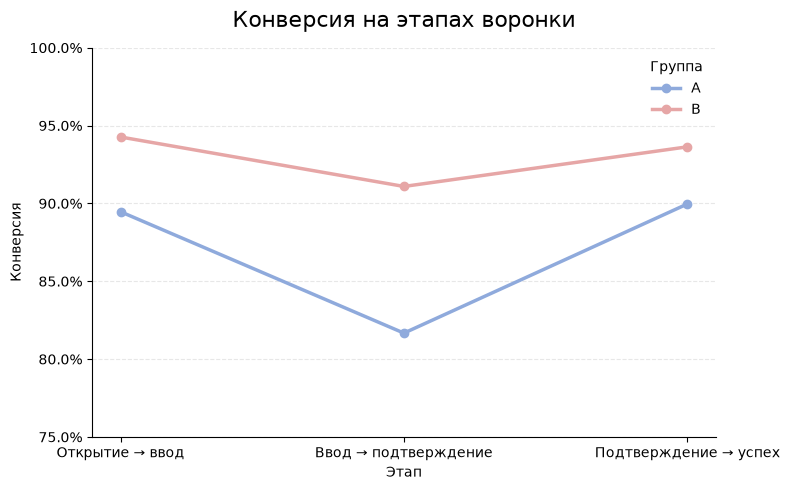

In [131]:
#визуализируем конверсию каждого этапа

stages = [
    'Открытие → ввод',
    'Ввод → подтверждение',
    'Подтверждение → успех'
]

a = [
    conversion_steps.loc['A', 'conversion_1'],
    conversion_steps.loc['A', 'conversion_2'],
    conversion_steps.loc['A', 'conversion_3']
]

b = [
    conversion_steps.loc['B', 'conversion_1'],
    conversion_steps.loc['B', 'conversion_2'],
    conversion_steps.loc['B', 'conversion_3']
]

fig, ax = plt.subplots(figsize=(8, 5))

x = range(len(stages))

ax.plot(
    x, a,
    marker='o',
    linewidth=2.5,
    label='A',
    color='#8FAADC'
)

ax.plot(
    x, b,
    marker='o',
    linewidth=2.5,
    label='B',
    color='#E6A6A6'
)

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.tick_params(axis='x', labelrotation=0)

ax.set_ylim(0.75, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_title(
    'Конверсия на этапах воронки',
    fontsize=16,
    pad=15
)

ax.set_xlabel('Этап')
ax.set_ylabel('Конверсия')

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    title='Группа',
    frameon=False
)

plt.tight_layout()
plt.show()

In [132]:
#статистический тест по каждому этапу

success = [493, 603]
confirmed = [548, 644]
entered = [671, 707]
total = [750, 750]

z, p_value = proportions_ztest(entered, total)

print('Открытие - ввод')
print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z, p_value = proportions_ztest(confirmed, entered)

print()
print('Ввод - подтверждение')
print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

z, p_value = proportions_ztest(success, confirmed)

print()
print('Подтверждение - успех')
print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

Открытие - ввод
z: -3.400506475286799
p-value: 0.0006726114283674043
Разница статистичеcки значима

Ввод - подтверждение
z: -5.115050907110753
p-value: 3.13656352334174e-07
Разница статистичеcки значима

Подтверждение - успех
z: -2.320603040509497
p-value: 0.020308277949421725
Разница статистичеcки значима


**Результат**: Конверсия выросла на каждом этапе воронки. Наибольший прирост конверсии наблюдается на этапе перехода от ввода данных к подтверждению: +9,4 п.п. (от 81,7% в группе А к 91,1% в группе В). В группе А на этапе перехода от ввода данных к их подтверждению происходит наибольшее падение конверсии.  

Разница статистически значима. Нулевая гипотеза отклонена.

### H3: Новая форма оплаты сокращает время прохождения успешного платежа.
### H0: Время прохождения успешного платежа в группах A и B не различается.

In [133]:
#Добавляем информацию, сколько минут занимает переход от одного этапа к следующему и общее время от входа до успешной оплаты

payments['time_1'] = (payments['step2_entered'] - payments['step1_opened']).dt.total_seconds() / 60
payments['time_2'] = (payments['step3_confirmed'] - payments['step2_entered']).dt.total_seconds() / 60
payments['time_3'] = (payments['step4_success'] - payments['step3_confirmed']).dt.total_seconds() / 60
payments['time_total'] = (payments['step4_success'] - payments['step1_opened']).dt.total_seconds() / 60

In [134]:
payments.groupby('group')[['time_1', 'time_2', 'time_3', 'time_total']].median()

,time_1,time_2,time_3,time_total
group,,,,
A,1.0,4.0,6.0,12.0
B,1.0,4.0,6.0,12.0


In [135]:
payments.groupby('group')[['time_1', 'time_2', 'time_3', 'time_total']].mean()

,time_1,time_2,time_3,time_total
group,,,,
A,2.356268,4.556728,5.480799,12.419355
B,2.428811,4.433333,5.475862,12.354023


In [136]:
#Статистическая проверка
#Используем тест Манна-Уитни, т.к. он не требует нормального распределения данных и позволяет нам сравнить распрделения времени в группах А и В

time_a = payments.loc[
    (payments['group'] == 'A') &
    (payments['time_total'].notna()),
    'time_total'
]

time_b = payments.loc[
    (payments['group'] == 'B') &
    (payments['time_total'].notna()),
    'time_total'
]

stat, p_value = mannwhitneyu(time_a, time_b)

print('Медиана A:', time_a.median())
print('Медиана B:', time_b.median())
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

Медиана A: 12.0
Медиана B: 12.0
p-value: 0.43180284403443436


**Результат**: Медианное время прохождения оплаты одинаково в обеих группах - 12 минут. Статистическая проверка не выявила значимых различий.

**Вывод**: Гипотеза не подтверждена.

### H4: Новая форма снижает количество попыток до первой успешной оплаты.  
### H0: При использовании новой формы количество попыток, необходимых для успешной оплаты, не сокращается.

In [137]:
#добавляем информацию о том, какой по счету попыткой оплаты для пользователя является каждая запись об оплате

payments = payments.sort_values(['user_id', 'step1_opened'])
payments['attempt_number'] = payments.groupby('user_id').cumcount() + 1

In [138]:
#находим, для скольких пользователей первая успешная оплата была совершена с 1, 2, 3, 4 попытки

first_success = (
    payments[payments['step4_passed'] == 1]
    .groupby(['user_id', 'group'])['attempt_number']
    .min()
    .reset_index()
)
first_success.groupby('group')['attempt_number'].value_counts()

group  attempt_number
A      1                 381
       2                  89
       3                  21
       4                   2
B      1                 493
       2                  95
       3                  14
       4                   1
Name: count, dtype: int64

In [141]:
#Проверяем статистическую значимость
#Используем хи квадрат, т.к. мы проверяем, связано ли нахождение пользователей в группе А или В с их распределением на несколько категорий.

table = pd.crosstab(
    first_success['group'],
    first_success['attempt_number']
)

chi2, p_value, dof, expected = chi2_contingency(table)

print(table)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

attempt_number    1   2   3  4
group                         
A               381  89  21  2
B               493  95  14  1
p-value: 0.15145478634438025


**Результат**: В группе B больше пользователей совершают успешную оплату с 1 попытки и меньше - с 3-4.  

Cтатистически значимых различий в распределении количества попыток до первой успешной оплаты между группами не обнаружено. Нулевая гипотеза не отклонена.

### Дополнительный анализ:
### Различается ли доля пользователей, совершивших две и более успешные оплаты, между группами.

In [142]:
#добавим информацию о том, сколько попыток оплат совершил каждый пользователь

attempts = payments.groupby(['user_id', 'group']).size().reset_index(name='attempts')
attempts.groupby('group')['attempts'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,750.0,1.744000,0.897146,1.0,1.0,1.0,2.0,4.0
B,750.0,1.801333,0.906436,1.0,1.0,2.0,2.0,4.0


In [143]:
#посчитаем, сколько пользователей совершили 1, 2, 3 или 4 оплаты

successful_purchases = (
    payments[payments['step4_passed'] == 1]
    .groupby(['user_id', 'group'])
    .size()
    .reset_index(name='successful_purchases')
)

successful_purchases.groupby(
    ['group', 'successful_purchases']
).size()

group  successful_purchases
A      1                       357
       2                       115
       3                        20
       4                         1
B      1                       395
       2                       157
       3                        43
       4                         8
dtype: int64

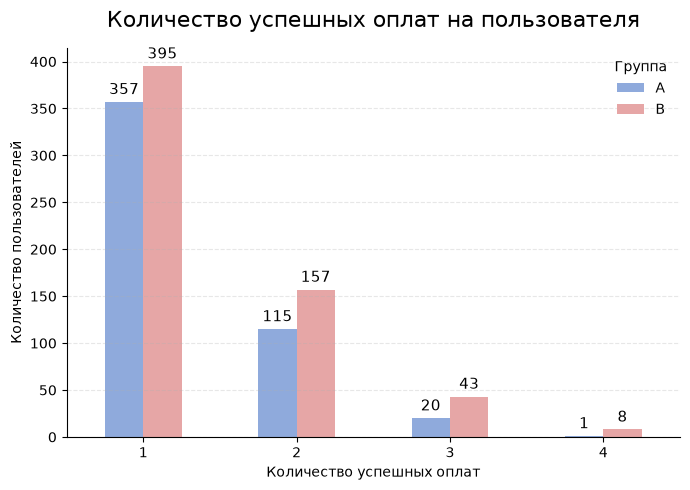

In [144]:
#визуализируем

plot_data = successful_purchases.groupby(
    ['successful_purchases', 'group']
).size().unstack('group')

fig, ax = plt.subplots(figsize=(7, 5))

plot_data.plot(
    kind='bar',
    ax=ax,
    color=['#8FAADC', '#E6A6A6']
)

ax.set_title('Количество успешных оплат на пользователя', fontsize=16, pad=15)
ax.set_xlabel('Количество успешных оплат')
ax.set_ylabel('Количество пользователей')
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels(plot_data.index, rotation=0)

ax.legend(title='Группа', frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# значения над столбиками
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [146]:
#Статистическая проверка результата: пользователи В чаще платя 2 и более раз

#данные

twice = [136, 208]
total = [493, 603]

#расчет
z, p_value = proportions_ztest(twice, total)

print(f'Доля повторных оплат в группе А: {136 / 493:.1%}')
print(f'Доля повторных оплат в группе B: {208 / 603:.1%}')
print('z:', z)
print('p-value:', p_value)
if p_value < 0.05:
    print('Разница статистичеcки значима')

Доля повторных оплат в группе А: 27.6%
Доля повторных оплат в группе B: 34.5%
z: -2.4516071283535217
p-value: 0.014221984514902931
Разница статистичеcки значима


**Результат**: Повторные оплаты чаще совершаются пользователями в группе В. Пользователи группы А совершили 158 повторных оплат, в группе В - 267. В группе А 27,6% пользователей совершают 2 и более оплаты, в группе В данная доля составляет 34,5%.  

Разница статистически значима.

### H5: Новая форма вызывает ошибки, из-за которых оплата одного и того же чека происходит несколько раз.  
### Н0: Новая форма не вызывает ошибки. Причины повторных оплат другие.

In [147]:
#добавим данные о предыдущей оплате каждым пользователем и о количестве дней между двумя соседними оплатами

payments = payments.sort_values(['user_id', 'step1_opened'])
payments['prev_payment'] = payments.groupby('user_id')['step1_opened'].shift(1)
payments['days_between'] = (
    payments['step1_opened'] - payments['prev_payment']
).dt.total_seconds() / 86400

In [148]:
payments[payments['days_between'].notna()].groupby('group')['days_between'].median()

group
A    7.384722
B    6.636806
Name: days_between, dtype: float64

In [149]:
#посчитаем, сколько раз оплаты были совершены несколько раз за сутки

short_interval = (
    payments[payments['days_between'].notna()]
    .groupby('group')['days_between']
    .agg(
        total='count',
        less_than_day=lambda x: (x < 1).sum()
    )
)

short_interval['share'] = (
    short_interval['less_than_day'] / short_interval['total']
)

short_interval

,total,less_than_day,share
group,,,
A,558,47,0.084229
B,601,38,0.063228


**Результат**: Не хватает данных о номере счета или о сумме оплаты для проверки данной гипотезы. На основе данных можно проверить время проведения оплаты. Медианный интервал между повторной оплатой и предыдущей в каждой группе составляет около недели (7,38 дней для группы А, 6,64 - для группы В). Кроме того, доля повторных платежей с интервалом менее суток составляет 8,4% в A и 6,3% в B.  

**Вывод**: Имеющиеся данные не дают оснований для подтверждения гипотезы об ошибочных списаниях. Однако для их точного опровержения также не хватает данных о счетах.

## Рекомендации

1. A/B-тест показал статистически значимый рост конверсии при использовании новой формы оплаты: с 65,7% до 80,4% (+14,7 п.п.). На основании результатов теста новую форму целесообразно внедрить для всех пользователей.
2. Наибольший прирост наблюдается на переходе от ввода данных к подтверждению: +9,4 п.п. Это согласуется с гипотезой о пользе автозаполнения и указывает на этот этап как на ключевую точку улучшения воронки.
3. При этом время прохождения платежа практически не изменилось, а статистически значимого сокращения числа попыток до успешной оплаты обнаружить не удалось.
4. Стоит уточнить, по какой причине некоторые пользователи совершают несколько оплат в месяц и зависит ли это от интерфейса приложения. При необходимости можно учитывать сумму оплаты или индивидуальный индикатор счета.